In [2]:
%%html
<style>
.dataframe th {
    font-size: 18px;
}
.dataframe td {
    font-size: 20px;
}
</style>
%matplotlib inline
%config InlineBackend.figure_format='retina'

In [3]:
import sys,os
from os.path import basename
from glob import glob

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "serif"
from astropy.stats import sigma_clip
from astropy.io import fits
import pandas as pd
from natsort import natsorted 
sys.path.append('/data/des81.b/data/emarrufo/AstroSkipper_Analysis/astroskip/astroskip/image')
sys.path.append('/data/des81.b/data/emarrufo/AstroSkipper_Analysis/full_CCD_characterization/')
#from skipper_image import *
import warnings
warnings.filterwarnings("ignore")
#import peak_finding_algorithm 
#import fit_peaks
from matplotlib.font_manager import FontProperties
import matplotlib.font_manager as font_manager


In [6]:
qe_files=natsorted((glob('/Users/Nora/Research/Fermi/20260109_xenon_filter3/*.fits')))
qe_files_fz = natsorted((glob('/Users/Nora/Research/Fermi/20260109_xenon_filter3/*.fits')))
qe_files_qt = natsorted((glob('/Users/Nora/Research/Fermi/20260107_quartz_tungsten_final/*.fits')))
qe_files_fz_qt = natsorted((glob('/Users/Nora/Research/Fermi/20260107_quartz_tungsten_final/*.fits')))
qe_files_e=natsorted((glob('/Users/Nora/Research/Fermi/edgar_qe/*.fits')))
qe_files_fz_e = natsorted((glob('/Users/Nora/Research/Fermi/raw/*.fz')))
bckg = natsorted((glob('/Users/Nora/Research/Fermi/*.fz')))
print(len(qe_files), len(qe_files_fz))

90 90


In [4]:
def get_gain(image,plot=True,disp=True):
    hdus=4
    img = SkipperImage(image)
    img_os = img.getImages()
    gain=dict()
    gain_arr=list()
    for i in range(hdus):
        clipped_img_os = sigma_clip(img_os[i].flatten(),sigma=2.5)
        _, _, k =peak_finding_algorithm.get_peaks(clipped_img_os, plot=plot)
        
        gain_arr.append(k)
    
    gain_arr=np.array(gain_arr)
    gain_arr=np.nan_to_num(gain_arr)
    m = np.median(gain_arr[gain_arr > 0])
    gain_arr[gain_arr == 0] = m
    
    for i in range(hdus):
        gain.update({i:[gain_arr[i]]})

    if disp:
        df = pd.DataFrame(data=gain)
        df.style.set_table_attributes('style="font-size: 17px"')
        
        title="Gain Measurments (ADUs/e-)"
        display(Markdown('<strong>{}'.format(title)))
        display(df)
    
    return np.array(gain_arr)


In [4]:
def get_power(raw_qe_files):
    power=list()
    for fz in raw_qe_files:
        hdr=fits.open(fz)[0].header
        power.append(hdr['POWER'])
    
    return power 

def get_waves(raw_qe_files):
    waves=list()
    for fz in raw_qe_files:
        hdr=fits.open(fz)[0].header
        waves.append(hdr['WAVE'])
    
    return waves 

    
    
    

In [7]:
def rel_QE(files,files_raw,hdu):
    rel_qe = list()
    n_phot=list()
    qe_errors = list()
    
    # Constants 
    h=6.625e-34
    c=2.998e8
    
    #gain 
    gain=[140, 140, 140, 140]
    print(gain)
    
    #power 
    power = get_power(files_raw)
    
    #wavelength 
    
    waves = get_waves(files_raw)

    #CCD area parameters 
    OSS=3080
    row_min=50
    row_max=500
    col_min=3050
    
    
    for i,f in enumerate(files):
        
        img=fits.open(f)
        
        os=sigma_clip(img[hdu].data[:,OSS:].flatten(),maxiters=None)
        OS= len(img[hdu].data[:,OSS:].flatten())
        act=sigma_clip(img[hdu].data[row_min:row_max,col_min:OSS].flatten(),maxiters=None)
        ACT=len(img[hdu].data[row_min:row_max,col_min:OSS].flatten())
    
      
        # Compute relative QE 
        activeMean=np.mean(act)
        osMean=np.mean(os)
        mean=activeMean-osMean
        
        # Convert from ADUs to elelctrons 
        meanElectron=mean/gain[hdu]
        
        sigma_act = np.std(act)
        sigma_os = np.std(os)
        error_meanElectron = np.sqrt(sigma_act**2 / ACT + sigma_os**2 / OS) / gain[hdu]    
    
        
        
        
        # Compute number of photons at the power meter and relative QE
        nPhot=(power[i]*waves[i])/(h*c)
        n_phot.append(nPhot)
        
        qe = meanElectron/nPhot
        rel_qe.append(qe)
        
        error_power = 0.04
        error_nPhot = (power[i]*error_power * waves[i]) / (h * c)
        
        error_qe = qe * np.sqrt((error_meanElectron / meanElectron)**2 + (error_nPhot / nPhot)**2)
        
        #error_qe  = error_meanElectron / nPhot
        qe_errors.append(error_qe)
    
    return np.array(rel_qe), np.array(waves), np.array(power), np.array(qe_errors)



        

    
qe, wav, power,error_QE= rel_QE(qe_files,qe_files_fz,1)
qe_qt, wav_qt, power_qt, error_QE_qt = rel_QE(qe_files_qt, qe_files_fz_qt, 1)
qe_e, wav_e, power_e ,error_QE_e = rel_QE(qe_files_e,qe_files_fz_e,1)
print(qe_qt)
print(qe[34])

[140, 140, 140, 140]
[140, 140, 140, 140]
[140, 140, 140, 140]
[5.40185457e-17 5.15651624e-17 5.04588977e-17 5.08644054e-17
 5.99702866e-17 6.50444865e-17 6.76213551e-17 6.98546389e-17
 7.52064882e-17 6.86791883e-17 7.88350704e-17 6.24748964e-17
 6.05776823e-17 6.80221908e-17 7.57853517e-17 7.96917721e-17
 8.65563019e-17 8.77393558e-17 9.70900255e-17 9.15403061e-17
 9.62377739e-17 1.01007497e-16 1.07077785e-16 1.07081680e-16
 1.23393148e-16 1.26631103e-16 3.23629737e-17 3.28962653e-17
 3.32094246e-17 3.38270646e-17 3.42898385e-17 3.47859204e-17
 3.53011595e-17 3.58569089e-17 3.61845900e-17 3.65933828e-17
 3.70458042e-17 3.71220405e-17 3.69780446e-17 3.71327583e-17
 3.71681727e-17 3.71025652e-17 3.69338788e-17 3.67179919e-17
 3.65910077e-17]
3.30327580200324e-15


In [8]:
# Normalized QE to AstroSkipper 20 abs QE 
rel_qe_norm_e=qe_e*0.72650889/(qe_e[-3])

scale = rel_qe_norm_e[24]/qe[24]
print(wav_e[30], wav_qt[15])
scale_qt = rel_qe_norm_e[30]/qe_qt[15]
print(scale)
rel_qe_norm = qe*0.72650889*scale
rel_qe_norm_qt = qe_qt*scale_qt
EQ_me = (error_QE)
EQ_me = (EQ_me)*scale 
EQ_qt = (error_QE_qt)
EQ_qt = (EQ_qt)*scale

print(EQ_qt)
EQ = (error_QE_e)
EQ = (EQ)/(qe_e[-3])
print(rel_qe_norm_e[24])

400.0 400.0
165543838904112.3
[0.00036666 0.00035013 0.00034387 0.00034631 0.00040872 0.0004432
 0.00046179 0.00047576 0.00051281 0.00046888 0.00053744 0.00042566
 0.00041027 0.00045893 0.00050845 0.00053288 0.00057702 0.00058366
 0.00064506 0.00060751 0.00063835 0.00066967 0.00070968 0.00070961
 0.00081762 0.00083894 0.00021439 0.00021791 0.00021997 0.00022406
 0.00022711 0.00023039 0.0002338  0.00023748 0.00023965 0.00024235
 0.00024534 0.00024584 0.00024489 0.00024591 0.00024614 0.00024571
 0.00024459 0.00024316 0.00024231]
0.4079905538257839


# Plotting 

45 45 45
86 86


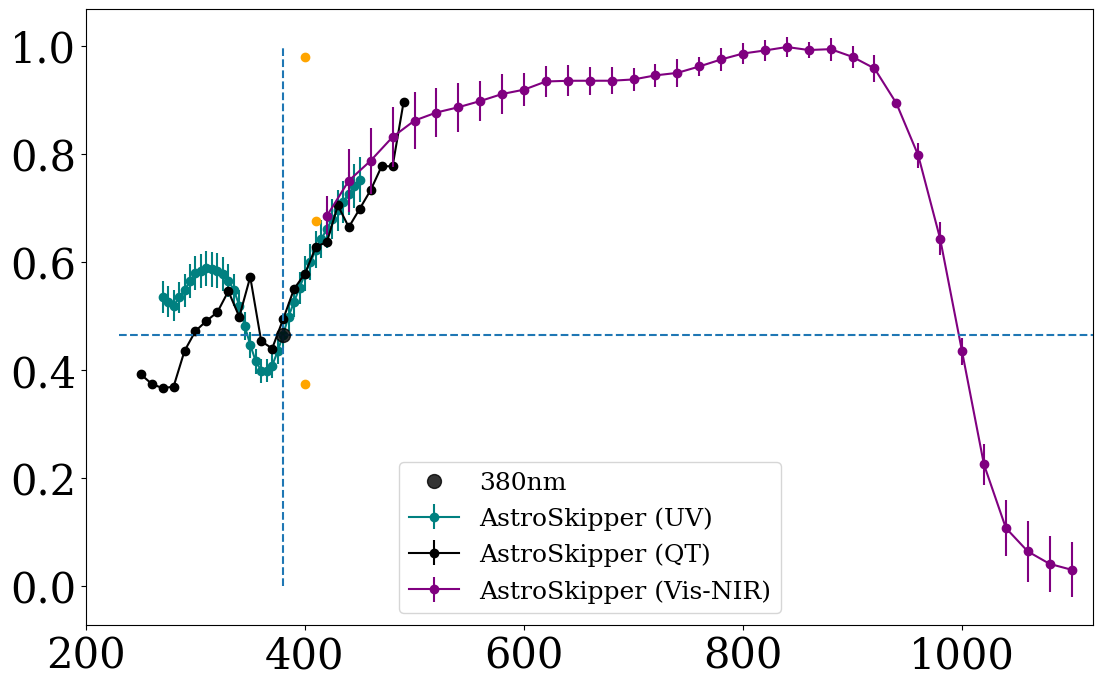

35
35
36


In [12]:
# Absolute QE (AstroSkipper#20)

W =[420.0, 440.0, 460.0, 480.0, 500.0, 520.0, 540.0, 560.0, 580.0, 600.0, 620.0, 640.0, 660.0, 680.0, 700.0, 720.0, 740.0, 760.0, 780.0, 800.0, 820.0, 840.0, 860.0, 880.0, 900.0, 920.0, 940.0, 960.0, 980.0, 1000.0, 1020.0, 1040.0, 1060.0, 1080.0, 1100.0]
ABS_QE_A20=[0.6615938,0.72650889, 0.76328651, 0.80583127, 0.83530155, 0.84959197,
 0.85942182, 0.87032707, 0.88289634, 0.89109827, 0.90563583, 0.90698798,
 0.90703812, 0.90676107, 0.90944294, 0.91636879, 0.92116129, 0.93257678,
 0.94486212, 0.95553663, 0.96096762, 0.96708218, 0.96157658, 0.96301167,
 0.94897208, 0.92824376, 0.86574196, 0.77150932, 0.62168514, 0.41981928,
 0.21731993, 0.103645,   0.06166894, 0.03948492, 0.0289835 ]


ABS_QE_A20=[0.68513775, 0.75022401 ,0.78734541, 0.83117725 ,0.86149584 ,0.87643427,
 0.88617632, 0.89765229, 0.91066856, 0.91872726 ,0.93389041 ,0.93515971,
 0.9352455,  0.93526966, 0.93765606, 0.94520705, 0.94978819, 0.96162882,
 0.97467413, 0.98565014, 0.99129811, 0.9977037,  0.99210105, 0.99372865,
 0.97940959, 0.95810742, 0.89362245, 0.79705207, 0.6425912 , 0.43411189,
 0.22491217, 0.10732945, 0.06401762 ,0.04092582, 0.03003962,]

qe_error = np.array([5.01064768,  3.61419069,  5.88335073,  6.12260305,  5.55555556,
        5.31079284,  4.60684206,  4.50933188,  3.75818282,  3.64411962,
        3.04314351,  2.92355098,  2.88575354,  2.56293146,  2.52097059,
        2.12402247,  2.11670624, 2.59069473,  1.78045994,  2.17980978,
        1.94928588,  1.97103749,  1.8002115 ,  1.47005277,  2.12794613,
        2.01370483,  2.46178457,  0.75568063,  2.31862306,  3.02821896,
        2.54505311,  3.75335121,  5.18991977,  5.57086062,  5.19527777,
        5.09337861])/100


#font = FontProperties(size= 35)
#plt.rcParams["font.family"] = "Cambria Math"
#font.set_style('normal')
#font2 = font_manager.FontProperties(family='Cambria Math',style='italic', size=20)

#plt.rcParams["font.family"] = "Cambria Math"
plt.rcParams["font.size"] = 35  # Set global font size

# Optional: Configure FontProperties for specific text elements
#font = FontProperties(size=35, family='Cambria Math', style='normal')


#h,q,w=np.loadtxt('/data/des81.b/data/emarrufo/AstroSkipper_Analysis/full_CCD_characterization/scintillation/qe.txt',usecols=(0,1,2),unpack=True)
#flaugher = pd.read_csv('/data/des81.b/data/emarrufo/AstroSkipper_Analysis/full_CCD_characterization/scintillation/decam_qe_flaugher.csv',comment='#')
       
fig, ax = plt.subplots(figsize=(13, 8))


print(len(wav_qt), len(rel_qe_norm_qt), len(EQ_qt))
#plt.plot(wav[4:],rel_qe_norm[4:],'o--',alpha=0.8,markersize=10,color='teal',label="AstroSkipper (UV)")
print(len(wav[4:]), len(rel_qe_norm[4:]))
plt.errorbar(wav_e[4:], rel_qe_norm_e[4:] ,yerr=EQ[4:], fmt='-o',color='teal', label="AstroSkipper (UV)",zorder=0)
#plt.errorbar(wav[4:37], rel_qe_norm[4:37] ,yerr=EQ_me[4:37], fmt='-o',color='red', label="AstroSkipper (Xe)",zorder=0)
plt.errorbar(wav_qt[:25], rel_qe_norm_qt[:25] ,yerr=abs(EQ_qt[:25]), fmt='-o',color='black', label="AstroSkipper (QT)",zorder=0)
#plt.plot(wav[4:37], rel_qe_norm[4:37], 'o', color='red', label="AstroSkipper (me)", zorder=0)
#plt.plot(wav_e[4:], rel_qe_norm_e[4:], 'o', color='red', label="AstroSkipper (edgar)", zorder=0)
#plt.plot(W,ABS_QE_A20,'o--',alpha=0.8,markersize=10,color='slategrey',label="AstroSkipper (VISNIR)")

plt.errorbar(W,ABS_QE_A20, yerr=qe_error[1:], fmt='-o',color='purple',label="AstroSkipper (Vis-NIR)",zorder=1)

'''
plt.plot(flaugher['wave'],flaugher['qe']/flaugher['qe'].max(),
                ls='-',lw=4,color='gray',
                 label='DECam',zorder=3,alpha=0.6)

plt.plot(w[0:61],q[0:61],lw=4,color='black',label='DESI',zorder=4,alpha=0.6)
'''




#plt.plot(W,ABS_QE_A20,'o',alpha=0.8,markersize=10,color='slategrey')
plt.vlines(380,ymin=0,ymax=1,linestyle='--',linewidth=1.5)
plt.hlines(0.46541516, 230,1200,linestyle='--',linewidth=1.5)
plt.plot(380,0.46541516,'o',alpha=0.8,markersize=10,color='black',label="380nm",zorder=2)
plt.plot(400, 0.374, 'o', color = 'orange')
plt.plot(410, 0.676, 'o', color = 'orange')
plt.plot(400, 0.979, 'o', color = 'orange')


#ax.set_xlabel('Wavelength (nm)',fontproperties=font)
#ax.set_ylabel('QE',fontproperties=font)
ax.tick_params(axis='both', which='major', labelsize=30)
plt.legend(fontsize=18,loc='lower center')
plt.savefig("UV_QE.pdf", bbox_inches='tight')
plt.xlim(200,1120)
#plt.ylim(0,1.03)
plt.savefig("UV_QE.pdf", bbox_inches='tight')

plt.show()


#print(wav[4:-7])
#print(rel_qe_norm[4:-7])

#QE_UV_params = [wav[4:-7],rel_qe_norm[4:-7]]

#np.save('/data/des81.b/data/emarrufo/AstroSkipper_Analysis/full_CCD_characterization/scintillation/QE_UV_params.npy',QE_UV_params)

print(len(ABS_QE_A20))
print(len(W))
print(len(qe_error))

#abs_QE_params =[W,ABS_QE_A20]
#np.save('/data/des81.b/data/emarrufo/AstroSkipper_Analysis/full_CCD_characterization/scintillation/abs_QE_params.npy',abs_QE_params)



# Absolute Calibration(UV)

In [ ]:
data_calibration=(natsorted((glob('/data/des81.b/data/emarrufo/AstroSkipper_Analysis/full_CCD_characterization/relative_QE/UV_ABS_Calibration/*.npy'))))
w =  np.array(list(range(350,500,5)))

# Photodiode calibration values from THORLABS
wave_photodiode, responsivity = np.loadtxt('thorlabs_photo_diode_calibration_full.txt',
                                           usecols=(0,1), 
                                            skiprows=(1), 
                                           unpack=True,delimiter=",")

# Match data
wave_photodiode=wave_photodiode[:-61]
responsivity=responsivity[:-61]

def calculate_power(photo_current,responsivity):
    area_ratio = (0.01)**2 / (1.5e-5)**2 
    power = photo_current/responsivity
    return power/area_ratio


def get_current(files,w,cube=False):
    for f in files:
        data=np.abs(np.load(f))
        data=data.reshape(int(len(w)),int(len(data)/len(w)))
        data_median = np.where(np.median(data, axis=1) == 0, np.mean(data, axis=1), np.median(data, axis=1))
        if cube:
            data_median=data_median*1.e-9
    
    return data_median 

cube_current = get_current(data_calibration,w,cube=True)[::2]

cube_power = calculate_power(cube_current,responsivity)


plt.plot(wave_photodiode,cube_power)

print(cube_power)

# UV-Expoxy-Crystal

In [ ]:
path='/data/des81.b/data/emarrufo/AstroSkipper_Analysis/full_CCD_characterization/relative_QE/UV_epoxy_crytal/'
led_only = np.loadtxt(path+"LED_only_3.txt")
epoxy=np.loadtxt(path+"LED_Epoxy_2.txt")
crystal=np.loadtxt(path+"LED_Crystal.txt")
print(crystal)
print(epoxy)

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))
plt.scatter([1],np.median(led_only),alpha=0.8,s=300,color='purple',label="LED Only",marker='+')
plt.scatter([2],np.median(epoxy),alpha=0.8,s=300,color='orange',label="Epoxy",marker='o')
plt.scatter([3],np.median(crystal),alpha=0.8,s=300,color='green',label="Crystal",marker='H')


ax.set_xlabel('Measurement',fontproperties=font)
ax.set_ylabel('Power(W)',fontproperties=font)
ax.tick_params(axis='both', which='major', labelsize=30)
plt.ylim(1e-10,3e-9)
plt.legend(fontsize=20)

plt.show()



In [ ]:
# Photon Number 
h=6.625e-34
c=2.998e8
p_UV=np.median(led_only)
p_Epoxy = np.median(epoxy)
p_crystal = np.median(crystal)

nPhot_UV=(p_UV*295)/(h*c)
nPhot_Epoxy=(p_Epoxy*295)/(h*c)
nPhot_crystal= (p_crystal*382)/(h*c)

print(nPhot_UV/nPhot_Epoxy)
print(nPhot_Epoxy)
print(nPhot_crystal)


In [ ]:
print( 3.9831535489068186e+18 / 8.673958739788791e+17 )

In [ ]:
4.850549422885698e+18 - 8.673958739788791e+17 

# New Epoxy-Crystal Measurements (12/19)


In [ ]:
# LED only 
path='/data/des81.b/data/emarrufo/AstroSkipper_Analysis/full_CCD_characterization/relative_QE/01_22_2024_LED_tests/'

led_only_filt_4 = np.loadtxt(path+'LED_only_coveredHoleWithClearPlasticTape_withFilter4_wav290nm_2024-01-22_100iterations_ConstCurrentMode.txt',max_rows=101, unpack=True)
led_only_filt_4_offset = np.loadtxt(path+'LED_only_coveredHoleWithClearPlasticTape_withFilter4_wav290nm_2024-01-22_100iterations_ConstCurrentMode.txt',skiprows=101, unpack=True)
led_only_filt_4 = led_only_filt_4 - np.median(led_only_filt_4_offset) 

led_only_filt_3 = np.loadtxt(path+'LED_only_withFilter3_wav290nm_2024-01-22.txt',max_rows=10, unpack=True)
led_only_filt_3_offset = np.loadtxt(path+'LED_only_withFilter3_wav290nm_2024-01-22.txt',skiprows=10, unpack=True)
led_only_filt_3 = np.median(led_only_filt_3_offset) - led_only_filt_3 

print(led_only_filt_4)

'''

# LED + Expoxy 

epoxy_filt_4 = np.loadtxt(path+'LED_Epoxy_withFilter4_wav290nm_2023-12-18.txt',max_rows=10, unpack=True)
epoxy_filt_4_offset = np.loadtxt(path+'LED_Epoxy_withFilter4_wav290nm_2023-12-18.txt',skiprows=10, unpack=True)
epoxy_filt_4 = epoxy_filt_4 - np.median(epoxy_filt_4_offset) 

# LED + Epoxy + Crystal

crystal_filt_1 = np.loadtxt(path+'LED_Crystal_withFilter1_wav290nm_2023-12-18.txt',max_rows=10, unpack=True)
crystal_filt_offset = np.loadtxt(path+'LED_Crystal_withFilter1_wav290nm_2023-12-18.txt',skiprows=10, unpack=True)
crystal_filt_1 = crystal_filt_1 - np.median(crystal_filt_offset) 

crystal_filt_4 = np.loadtxt(path+'LED_Crystal_withFilter4_wav290nm_2023-12-18.txt',max_rows=10, unpack=True)
crystal_filt_offset_4 = np.loadtxt(path+'LED_Crystal_withFilter4_wav290nm_2023-12-18.txt',skiprows=10, unpack=True)
crystal_filt_4 = crystal_filt_4 - np.median(crystal_filt_offset_4)

crystal_filt_3 = np.loadtxt(path+'LED_Crystal_withFilter3_wav380nm_2023-12-18.txt',max_rows=10, unpack=True)
crystal_filt_offset_3 = np.loadtxt(path+'LED_Crystal_withFilter3_wav380nm_2023-12-18.txt',skiprows=10, unpack=True)
crystal_filt_3 = crystal_filt_3 - np.median(crystal_filt_offset_3)

'''






In [ ]:
# Plotting 

fig, ax = plt.subplots(figsize=(8, 8))
plt.scatter(np.arange(len(led_only_filt_4)),led_only_filt_4,alpha=0.8,s=300,color='purple',marker='+')
#plt.hlines(np.median(led_only_filt_4),-1,10,linestyle='--',color='purple',label='LED filter 4 (median)')


#plt.scatter(np.arange(len(led_only_filt_3)),led_only_filt_3,alpha=0.8,s=300,color='red',marker='o')
#plt.hlines(np.median(led_only_filt_3),-1,10,linestyle='--',color='green',label='LED filter 3 (median)')

# Epoxy 

#plt.scatter(np.arange(len(epoxy_filt_4)),epoxy_filt_4,alpha=0.8,s=300,color='red',marker='+')
#plt.hlines(np.median(epoxy_filt_4),-1,10,linestyle='--',color='red',label='LED+Epoxy filter 4 (median)')

# Crystal 

#plt.scatter(np.arange(len(crystal_filt_1)),crystal_filt_1,alpha=0.8,s=300,color='orange',marker='+')
#plt.hlines(np.median(crystal_filt_1),-1,10,linestyle='--',color='orange',label='Crystal filter 1 (median)')


#plt.scatter(np.arange(len(crystal_filt_4)),crystal_filt_4,alpha=0.8,s=300,color='orange',marker='+')
#plt.hlines(np.median(crystal_filt_4),-1,10,linestyle='--',color='orange',label='Crystal filter 4 (median)')

#plt.scatter(np.arange(len(crystal_filt_3)),crystal_filt_3,alpha=0.8,s=300,color='orange',marker='+')
#plt.hlines(np.median(crystal_filt_3),-1,10,linestyle='--',color='orange',label='Crystal filter 3 (median)')







ax.set_xlabel('Measurement',fontproperties=font)
ax.set_ylabel('Power(W)',fontproperties=font)
ax.tick_params(axis='both', which='major', labelsize=30)
plt.legend(fontsize=20)
plt.ylim(3.0e-10,3.90e-10)
#plt.xlim(-1,10)

plt.show()



In [ ]:
print(np.median(crystal_filt_4)/np.median(epoxy_filt_4))

In [ ]:
print(np.mean(led_only_filt_4))

# UV LAMP and Crystal Measurments

In [ ]:
#data_lamp=natsorted((glob('/data/des81.b/data/emarrufo/AstroSkipper_Analysis/full_CCD_characterization/relative_QE/qe_20240125_01/proc_*.fits')))
#data_raw_lamp=natsorted((glob('/data/des81.b/data/emarrufo/AstroSkipper_Analysis/full_CCD_characterization/relative_QE/qe_20240125_01/*.fz')))


#POW = get_power(data_raw_lamp)
#WAV = get_waves(data_raw_lamp)
#WAV=np.unique(WAV)
#POW=np.array(POW).reshape(40,20)

data_lamp=natsorted((glob('/data/des81.b/data/emarrufo/AstroSkipper_Analysis/full_CCD_characterization/relative_QE/qe_20240131_01/proc_*.fits')))
data_raw_lamp=natsorted((glob('/data/des81.b/data/emarrufo/AstroSkipper_Analysis/full_CCD_characterization/relative_QE/qe_20240131_01/*.fz')))


POW = get_power(data_raw_lamp)
WAV = get_waves(data_raw_lamp)
WAV=np.unique(WAV)
POW=np.array(POW).reshape(int(len(data_lamp)/5),5)



#data_epoxy=natsorted((glob('/data/des81.b/data/emarrufo/AstroSkipper_Analysis/full_CCD_characterization/relative_QE/qe_20240129_00/proc_*.fits')))
#data_raw_epoxy=natsorted((glob('/data/des81.b/data/emarrufo/AstroSkipper_Analysis/full_CCD_characterization/relative_QE/qe_20240129_00/*.fz')))


#POW_e = get_power(data_raw_epoxy)
#WAV_e = get_waves(data_raw_epoxy)
#WAV_e=np.unique(WAV_e)
#POW_e=np.array(POW_e).reshape(int(len(data_epoxy)/10),10)



data_epoxy=natsorted((glob('/data/des81.b/data/emarrufo/AstroSkipper_Analysis/full_CCD_characterization/relative_QE/qe_20240131_00/proc_*.fits')))
data_raw_epoxy=natsorted((glob('/data/des81.b/data/emarrufo/AstroSkipper_Analysis/full_CCD_characterization/relative_QE/qe_20240131_00/*.fz')))


POW_e = get_power(data_raw_epoxy)
WAV_e = get_waves(data_raw_epoxy)
WAV_e=np.unique(WAV_e)
POW_e=np.array(POW_e).reshape(int(len(data_epoxy)/5),5)


data_epoxy_2=natsorted((glob('/data/des81.b/data/emarrufo/AstroSkipper_Analysis/full_CCD_characterization/relative_QE/qe_epoxy_20240202_00/proc_*.fits')))
data_raw_epoxy_2=natsorted((glob('/data/des81.b/data/emarrufo/AstroSkipper_Analysis/full_CCD_characterization/relative_QE/qe_epoxy_20240202_00/*.fz')))


POW_e_2 = get_power(data_raw_epoxy_2)
WAV_e_2 = get_waves(data_raw_epoxy_2)
WAV_e_2=np.unique(WAV_e_2)
POW_e_2=np.array(POW_e_2).reshape(int(len(data_epoxy_2)/2),2)


data_c=natsorted((glob('/data/des81.b/data/emarrufo/AstroSkipper_Analysis/full_CCD_characterization/relative_QE/qe_crystal_20240202_00/proc_*.fits')))
data_raw_c=natsorted((glob('/data/des81.b/data/emarrufo/AstroSkipper_Analysis/full_CCD_characterization/relative_QE/qe_crystal_20240202_00/*.fz')))


POW_c = get_power(data_raw_c)
WAV_c = get_waves(data_raw_c)
WAV_c=np.unique(WAV_c)
POW_c=np.array(POW_c).reshape(int(len(data_c)/2),2)


data_dark=natsorted((glob('/data/des81.b/data/emarrufo/AstroSkipper_Analysis/full_CCD_characterization/relative_QE/qe_dark_20240202_00/proc_*.fits')))
data_raw_dark=natsorted((glob('/data/des81.b/data/emarrufo/AstroSkipper_Analysis/full_CCD_characterization/relative_QE/qe_dark_20240202_00/*.fz')))


POW_dark = get_power(data_raw_dark)
WAV_dark = get_waves(data_raw_dark)
WAV_dark=np.unique(WAV_dark)
POW_dark=np.array(POW_dark).reshape(int(len(data_dark)/2),2)



pow_median = np.mean(POW,axis=1)
pow_median_e = np.mean(POW_e,axis=1)
pow_median_e_2 = np.mean(POW_e_2,axis=1)
pow_median_c = np.mean(POW_c,axis=1)
pow_median_dark = np.mean(POW_dark,axis=1)



# 380nm filter 

data_lamp_380=natsorted((glob('/data/des81.b/data/emarrufo/AstroSkipper_Analysis/full_CCD_characterization/relative_QE/qe_lamp_only_380nm_filter_20240205_00/proc_*.fits')))
data_raw_lamp_380=natsorted((glob('/data/des81.b/data/emarrufo/AstroSkipper_Analysis/full_CCD_characterization/relative_QE/qe_lamp_only_380nm_filter_20240205_00/*.fz')))


POW_lamp_380 = get_power(data_raw_lamp_380)
WAV_lamp_380 = get_waves(data_raw_lamp_380)
WAV_lamp_380=np.unique(WAV_lamp_380)
POW_lamp_380=np.array(POW_lamp_380).reshape(int(len(data_lamp_380)/2),2)


pow_median_lamp_380 = np.mean(POW_lamp_380,axis=1)


data_control_380=natsorted((glob('/data/des81.b/data/emarrufo/AstroSkipper_Analysis/full_CCD_characterization/relative_QE/qe_control_380nm_filter_20240205_00/proc_*.fits')))
data_raw_control_380=natsorted((glob('/data/des81.b/data/emarrufo/AstroSkipper_Analysis/full_CCD_characterization/relative_QE/qe_control_380nm_filter_20240205_00/*.fz')))


POW_control_380 = get_power(data_raw_control_380)
WAV_control_380 = get_waves(data_raw_control_380)
WAV_control_380=np.unique(WAV_control_380)
POW_control_380=np.array(POW_control_380).reshape(int(len(data_control_380)/2),2)


pow_median_control_380 = np.mean(POW_control_380,axis=1)


data_c_380=natsorted((glob('/data/des81.b/data/emarrufo/AstroSkipper_Analysis/full_CCD_characterization/relative_QE/qe_crystal_380nm_filter_20240205_00/proc_*.fits')))
data_raw_c_380=natsorted((glob('/data/des81.b/data/emarrufo/AstroSkipper_Analysis/full_CCD_characterization/relative_QE/qe_crystal_380nm_filter_20240205_00/*.fz')))


POW_c_380 = get_power(data_raw_c_380)
WAV_c_380 = get_waves(data_raw_c_380)
WAV_c_380=np.unique(WAV_c_380)
POW_c_380=np.array(POW_control_380).reshape(int(len(data_c_380)/2),2)


pow_median_c_380 = np.mean(POW_c_380,axis=1)




In [ ]:
#pow_median = np.mean(POW,axis=1)
#pow_median_e = np.mean(POW_e,axis=1)


fig, ax = plt.subplots(figsize=(8, 8))
plt.plot(WAV,pow_median,alpha=0.8,color='purple')
plt.plot(WAV_e,pow_median_e)
ax.set_xlabel('Wavelength',fontproperties=font)
ax.set_ylabel('Power(W)',fontproperties=font)
ax.tick_params(axis='both', which='major', labelsize=30)
plt.legend(fontsize=20)
#plt.ylim(1.9e-11,5.9e-9)
plt.xlim(200,500)
plt.grid('both')
plt.show()

print(pow_median[np.where(WAV==290)][0])


In [ ]:
# Dector data 

def get_signal(files,hdu,waves,wave):
    
    signal_average=list()
    
    gain=138 
    
    OSS=3080
    row_min=10
    row_max=500
    col_min=3000
    
    
    
    for i,f in enumerate(files):
        img=fits.open(f)
        
        act=sigma_clip(img[hdu].data[row_min:row_max,col_min:OSS].flatten(),maxiters=None)
        
        activeMean=np.median(act)
        signal_average.append(activeMean)
    
    signal_average= np.array(signal_average).reshape(len(waves),int(len(files)/len(waves)))
    
    measurement_at_w = np.abs(signal_average[np.where(waves==wave)[0]])
    
    
    signal_average = np.median(np.abs(signal_average),axis=1)
    
    
    # Plotting 
    
    fig, ax = plt.subplots(figsize=(8, 8))
    plt.plot(waves,signal_average/gain,alpha=0.8,color='orange',label='Epoxy',linewidth=2)
    ax.set_xlabel('Wavelength',fontproperties=font)
    ax.set_ylabel('Signal(e-)',fontproperties=font)
    ax.tick_params(axis='both', which='major', labelsize=30)
    plt.legend(fontsize=20)
    plt.xlim(250,450)
    plt.grid('both')
    plt.show()
    
    fig, ax = plt.subplots(figsize=(8, 8))
    plt.scatter(np.arange(0,len(measurement_at_w[0]),1),measurement_at_w[0]/gain,alpha=0.8,
                s=300,color='purple',marker='+',label='Signal at {}nm'.format(wave))
    plt.axhline(y=np.median(measurement_at_w[0]/gain),
                linestyle='--',color='red',label="$\mu_s={0:.3g}e-$".format(np.median(measurement_at_w[0]/gain)))
    ax.set_xlabel('Measurement',fontproperties=font)
    ax.set_ylabel('Signal(e-)',fontproperties=font)
    ax.tick_params(axis='both', which='major', labelsize=30)
    plt.legend(fontsize=20)
    #plt.ylim(3.4,4)
    #plt.ylim(1.4,1.8)
    plt.grid('both')
    plt.show()

    
    
    
    
    
        
    
    return waves,signal_average,measurement_at_w


#w,s,m = get_signal(data_lamp,0,WAV,250)
#w_e,s_e,m_e = get_signal(data_epoxy,0,WAV_e,290)
#w_e_2,s_e_2,m_e_2 = get_signal(data_epoxy_2,0,WAV_e_2,290)
#w_c,s_c,m_c = get_signal(data_c,0,WAV_c,290)
#w_dark,s_dark,m_dark = get_signal(data_dark,0,WAV_dark,290)



# 380nm filter

#w_lamp_380,s_lamp_380,m_lamp_380 = get_signal(data_lamp_380,0,WAV_lamp_380,250)
#w_control_380,s_control_380,m_control_380 = get_signal(data_control_380,0,WAV_control_380,250)
#w_c_380,s_c_380,m_c_380 = get_signal(data_c_380,0,WAV_c_380,250)




In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))
plt.plot(w,(s/138)/np.max(s/138),alpha=0.8,color='orange',label='Lamp Only',linewidth=2)
#plt.plot(w_e,s_e/138,alpha=0.8,color='red',label='Epoxy',linewidth=2,zorder=0)
plt.plot(w_e_2,(s_e_2/138)/np.max(s_e_2/138),alpha=0.8,color='green',label='Epoxy',linewidth=2,zorder=1)
plt.plot(w_c,(s_c/138)/np.max(s_c/138),alpha=0.8,color='purple',label='Crystal',linewidth=2,zorder=2)
#plt.axhline(y=np.median((s_dark/138)),alpha=0.8,color='olive',label='Dark Exposure',linewidth=2,zorder=3, linestyle='--')




plt.yscale('log')

ax.set_xlabel('Wavelength',fontproperties=font)
ax.set_ylabel('Signal(e-)',fontproperties=font)
ax.tick_params(axis='both', which='major', labelsize=30)
plt.legend(fontsize=20)
plt.xlim(250,450)
#plt.ylim(0,10)


plt.grid('both')
plt.show()


fig, ax = plt.subplots(figsize=(8, 8))
plt.scatter(w,(s_c/138)/(s_e/138),alpha=0.8,color='red',s=300)

print((s/138))
print((s_e/138))


ax.set_xlabel('Wavelength',fontproperties=font)
ax.set_ylabel('Epoxy/Lamp',fontproperties=font)
ax.tick_params(axis='both', which='major', labelsize=30)
plt.legend(fontsize=20)
#plt.xlim(250,450)
#plt.ylim(0,10)
plt.grid('both')
plt.show()






fig, ax = plt.subplots(figsize=(8, 8))
plt.scatter(np.arange(0,len(m[0]),1),m[0]/138,alpha=0.8,
            s=300,color='green',marker='o',label="Lamp")
plt.scatter(np.arange(0,len(m_e[0]),1),m_e[0]/138,alpha=0.8,
            s=300,color='blue',marker='+',label='Epoxy')
ax.set_xlabel('Measurement',fontproperties=font)
ax.set_ylabel('Signal(e-)',fontproperties=font)
ax.tick_params(axis='both', which='major', labelsize=30)
plt.legend(fontsize=20)
#plt.ylim(2.0,4)
#plt.xlim(-1,20)
plt.grid('both')
plt.show() 


print(w)

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))
plt.plot(w_lamp_380,(s_lamp_380/138),alpha=0.8,color='orange',label='Lamp Only',linewidth=2)
#plt.plot(w_control_380,(s_control_380/138),alpha=0.8,color='green',label='Control',linewidth=2,zorder=1)
#plt.plot(w_c_380,(s_c_380/138),alpha=0.8,color='purple',label='Crystal',linewidth=2,zorder=1)

#plt.plot(w_c,(s_c/138)/np.max(s_c/138),alpha=0.8,color='purple',label='Crystal',linewidth=2,zorder=2)
#plt.axhline(y=np.median((s_dark/138)),alpha=0.8,color='olive',label='Dark Exposure',linewidth=2,zorder=3, linestyle='--')



#plt.yscale('log')

ax.set_xlabel('Lamp Wavelength',fontproperties=font)
ax.set_ylabel('Signal(e-)',fontproperties=font)
ax.tick_params(axis='both', which='major', labelsize=30)
plt.legend(fontsize=20)
#plt.xlim(250,420)
#plt.ylim(0,5)


plt.grid('both')
plt.show()


'''

fig, ax = plt.subplots(figsize=(8, 8))
plt.scatter(w,(s_c/138)/(s_e/138),alpha=0.8,color='red',s=300)
ax.set_xlabel('Wavelength',fontproperties=font)
ax.set_ylabel('Epoxy/Lamp',fontproperties=font)
ax.tick_params(axis='both', which='major', labelsize=30)
plt.legend(fontsize=20)
#plt.xlim(250,450)
#plt.ylim(0,10)
plt.grid('both')
plt.show()
'''



'''

fig, ax = plt.subplots(figsize=(8, 8))
plt.scatter(np.arange(0,len(m[0]),1),m[0]/138,alpha=0.8,
            s=300,color='green',marker='o',label="Lamp")
plt.scatter(np.arange(0,len(m_e[0]),1),m_e[0]/138,alpha=0.8,
            s=300,color='blue',marker='+',label='Epoxy')
ax.set_xlabel('Measurement',fontproperties=font)
ax.set_ylabel('Signal(e-)',fontproperties=font)
ax.tick_params(axis='both', which='major', labelsize=30)
plt.legend(fontsize=20)
#plt.ylim(2.0,4)
#plt.xlim(-1,20)
plt.grid('both')
plt.show() 


print(w)

'''

# Lamp-Filter (4) Mapping g=1

In [ ]:
wave_l, m1,m2 = np.loadtxt('./lamp_calibration_20240131_.txt', 
                           usecols=(0,1,2),skiprows=(1),unpack=True)

m_total = (m1+m2)/2

fig, ax = plt.subplots(figsize=(8, 8))
plt.plot(wave_l,m_total,alpha=0.8,color='orange',linewidth=2)

ax.set_xlabel('Wavelength',fontproperties=font)
ax.set_ylabel('Power(W)',fontproperties=font)
ax.tick_params(axis='both', which='major', labelsize=30)
plt.legend(fontsize=20)
plt.grid('both')
plt.xlim(200,450)
plt.yscale('log')
plt.show()

print(wave_l)


In [ ]:
print(np.where(wave_l ==740))
print(m_total[12]/m_total[47])
print(m_total[47])

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))
plt.plot(w_lamp_380,(s_lamp_380/138)/np.max((s_lamp_380/138)),alpha=0.8,color='orange',label='Lamp Only',linewidth=2)
plt.plot(w_control_380,(s_control_380/138)/np.max((s_control_380/138)),alpha=0.8,color='green',label='Control',linewidth=2,zorder=1)
plt.plot(w_c_380,(s_c_380/138)/np.max((s_c_380/138)),alpha=0.8,color='purple',label='Crystal',linewidth=2,zorder=1)

#plt.plot(w_c,(s_c/138)/np.max(s_c/138),alpha=0.8,color='purple',label='Crystal',linewidth=2,zorder=2)
#plt.axhline(y=np.median((s_dark/138)),alpha=0.8,color='olive',label='Dark Exposure',linewidth=2,zorder=3, linestyle='--')



#plt.yscale('log')

ax.set_xlabel('Lamp Wavelength',fontproperties=font)
ax.set_ylabel('Signal(e-)/Signal_max(e-)',fontproperties=font)
ax.tick_params(axis='both', which='major', labelsize=30)
plt.legend(fontsize=20)
#plt.xlim(250,420)
#plt.ylim(0,5)


plt.grid('both')
plt.show()

print(np.where((s_lamp_380/138) == np.max((s_lamp_380/138) )))
print(np.where((s_control_380/138) == np.max((s_control_380/138) )))
print(np.where((s_c_380/138) == np.max((s_c_380/138) )))



print(w_lamp_380[12])


In [ ]:
def signal_from_measurement(files,hdu,rmin,rmax,cmin):
    
    signal_average=list()
    
    gain=138 
    
    OSS=3080
    row_min= rmin #10
    row_max= rmax #500
    col_min= cmin #3000
    
    dark_rate = (2e-4) 
    
    
    
    for i,f in enumerate(files):
        img=fits.open(f)
        
        act=sigma_clip(img[hdu].data[row_min:row_max,col_min:OSS].flatten(),maxiters=None)
        
        activeMean=np.abs(np.median(act))
        signal_average.append(activeMean)
    
    
    return np.array(signal_average)/gain
    

    
    

In [ ]:
# LED configuration 

data_led=natsorted((glob('/data/des81.b/data/emarrufo/AstroSkipper_Analysis/full_CCD_characterization/relative_QE/LED_signal_char/data/signal_lamp_20240207_00/proc_*.fits')))
data_control=natsorted((glob('/data/des81.b/data/emarrufo/AstroSkipper_Analysis/full_CCD_characterization/relative_QE/LED_signal_char/data/signal_control_20240207_00/proc_*.fits')))
data_crystal=natsorted((glob('/data/des81.b/data/emarrufo/AstroSkipper_Analysis/full_CCD_characterization/relative_QE/LED_signal_char/data/signal_crystal_20240207_01/proc_*.fits')))
data_crystal_2=natsorted((glob('/data/des81.b/data/emarrufo/AstroSkipper_Analysis/full_CCD_characterization/relative_QE/LED_signal_char/data/signal_crystal_conf_2_20240207_01/proc_*.fits')))
UV_lamp_only=natsorted((glob('/data/des81.b/data/emarrufo/AstroSkipper_Analysis/full_CCD_characterization/relative_QE/qe_lamp_380nm_filter_20240209_00/proc_*.fits')))



#POW_led = get_power(data_raw_led)
#WAV_led = get_waves(data_raw_led)
#WAV_led=np.unique(WAV)
#POW_led=np.array(POW).reshape(int(len(data_lamp)/5),5)


s_led = signal_from_measurement(data_led,1,10,100,3000)
s_control = signal_from_measurement(data_control,0,10,600,100)
s_crystal_p1 = signal_from_measurement(data_crystal,0,10,500,3000)
s_crystal_p2 = signal_from_measurement(data_crystal_2,0,10,500,3000)
s_uv_lamp = signal_from_measurement(UV_lamp_only,0,10,500,3000)

print(np.median(s_led)/np.median(s_uv_lamp[:10]))



In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))
plt.scatter(np.arange(len(s_led)),s_led,alpha=0.8,s=300,color='purple',marker='+',label="LED")
plt.scatter(np.arange(len(s_control)),s_control,alpha=0.8,s=300,color='red',marker='o',label="Control")
plt.scatter(np.arange(len(s_crystal_p1)),s_crystal_p1,alpha=0.8,s=300,color='green',marker='X',label="Crystal Position 1")
plt.scatter(np.arange(len(s_crystal_p2)),s_crystal_p2,alpha=0.8,s=300,color='black',marker='<',label="Crystal Position 2")
plt.scatter(np.arange(len(s_uv_lamp)),s_uv_lamp,alpha=0.8,s=300,color='blue',marker='H',label="UV lamp")



ax.set_xlabel('Measurement',fontproperties=font)
ax.set_ylabel('Signal(e-)',fontproperties=font)
ax.tick_params(axis='both', which='major', labelsize=30)
plt.legend(fontsize=20)
plt.xlim(-1,10)
plt.show()

# 03-14-2024

Tests with new configuration: crystal + epoxy are downstream 

In [ ]:
waves =  (np.arange(250,470,10))
wav=np.arange(250,510,5)
w=(np.arange(250,480,10))
data_lamp_down = np.load('/data/des81.b/data/emarrufo/AstroSkipper_Analysis/full_CCD_characterization/relative_QE/03_14_2024_downstream/POWER_lamp_only.npy')
data_lamp_down = np.median(data_lamp_down,axis=1)

data_epoxy =  np.load('/data/des81.b/data/emarrufo/AstroSkipper_Analysis/full_CCD_characterization/relative_QE/03_14_2024_downstream/POWER_epoxy_in_path.npy')
data_epoxy = np.median(data_epoxy,axis=1)


data_epoxy2 =  np.load('/data/des81.b/data/emarrufo/AstroSkipper_Analysis/full_CCD_characterization/relative_QE/03_14_2024_downstream/POWER_epoxyl_on_path_2.npy')
data_epoxy2 = np.median(data_epoxy2,axis=1)



data_crystal =  np.load('/data/des81.b/data/emarrufo/AstroSkipper_Analysis/full_CCD_characterization/relative_QE/03_14_2024_downstream/POWER_crystal_on_path_2.npy')
data_crystal = np.median(data_crystal,axis=1)


data_crystal2 =  np.load('/data/des81.b/data/emarrufo/AstroSkipper_Analysis/full_CCD_characterization/relative_QE/03_14_2024_downstream/POWER_crystal_on_path_3.npy')
data_crystal2 = np.median(data_crystal2,axis=1)

data_crystal2[data_crystal2 <= 6e-12] = 0


data_crystal3 =  np.load('/data/des81.b/data/emarrufo/AstroSkipper_Analysis/full_CCD_characterization/relative_QE/03_14_2024_downstream/POWER_crystal_on_path_4.npy')
data_crystal3 = np.median(data_crystal3,axis=1)


In [ ]:
font = FontProperties(size= 35)
plt.rcParams["font.family"] = "Cambria Math"
font.set_style('normal')
font2 = font_manager.FontProperties(family='Cambria Math',style='italic', size=20)
       
fig, ax = plt.subplots(figsize=(8, 8))
#plt.plot(waves,data_lamp_down,color='purple',linestyle='--',label="Lamp + UV filter")
plt.plot(w,data_epoxy2,color='red',linestyle='-.',label="control")
#plt.plot(waves[1:],data_crystal[1:],color='black',linestyle='-',label="crystal",linewidth=2.5)
#plt.plot(wav,data_crystal2,color='black',linestyle='-',label="crystal",linewidth=2.5)
plt.plot(w,data_crystal3,color='green',linestyle='--',label="crystal",linewidth=2.5)






ax.set_xlabel('Mono Wavelenght(nm)',fontproperties=font)
ax.set_ylabel('Power (W)',fontproperties=font)
ax.tick_params(axis='both', which='major', labelsize=30)
plt.legend(fontsize=20)
#plt.ylim(1e-13,1.25e-10)
plt.xlim(200,470)
plt.yscale('log')
plt.savefig("crystal.pdf",bbox_inches='tight')
plt.show()

# CDD DATA

In [ ]:
data_control_skipper = natsorted((glob('/data/des81.b/data/emarrufo/AstroSkipper_Analysis/full_CCD_characterization/relative_QE/03_14_2024_downstream/qe_UVlamp_control_20240315_00/proc_*.fits')))
data_control_raw = natsorted((glob('/data/des81.b/data/emarrufo/AstroSkipper_Analysis/full_CCD_characterization/relative_QE/03_14_2024_downstream/qe_UVlamp_control_20240315_00/*.fz')))


data_crystal_skipper = natsorted((glob('/data/des81.b/data/emarrufo/AstroSkipper_Analysis/full_CCD_characterization/relative_QE/03_14_2024_downstream/qe_UVlamp_crystal_nsamp_1_20240315_00/proc_*.fits')))
data_crystal_raw = natsorted((glob('/data/des81.b/data/emarrufo/AstroSkipper_Analysis/full_CCD_characterization/relative_QE/03_14_2024_downstream/qe_UVlamp_crystal_nsamp_1_20240315_00/*.fz')))


data_lamp_skipper = natsorted((glob('/data/des81.b/data/emarrufo/AstroSkipper_Analysis/full_CCD_characterization/relative_QE/03_14_2024_downstream/qe_UVlamp_lamp_only_nsamp_1_20240419_00/proc_*.fits')))
data_lamp_raw = natsorted((glob('/data/des81.b/data/emarrufo/AstroSkipper_Analysis/full_CCD_characterization/relative_QE/03_14_2024_downstream/qe_UVlamp_lamp_only_nsamp_1_20240419_00/*.fz')))

data_open_skipper = natsorted((glob('/data/des81.b/data/emarrufo/AstroSkipper_Analysis/full_CCD_characterization/relative_QE/03_14_2024_downstream/qe_UVlamp_lamp_only_OPEN_nsamp_1_20240419_00/proc_*.fits')))
data_open_raw = natsorted((glob('/data/des81.b/data/emarrufo/AstroSkipper_Analysis/full_CCD_characterization/relative_QE/03_14_2024_downstream/qe_UVlamp_lamp_only_OPEN_nsamp_1_20240419_00/*.fz')))

dark = '/data/des81.b/data/emarrufo/AstroSkipper_Analysis/full_CCD_characterization/relative_QE/qe_dark_20240202_00/proc_qe_lta_t5.0_w250_n1_i0_101.fits'

wav_c = get_waves(data_control_raw)
wav_crystal = get_waves(data_crystal_raw)
wav_lamp =  get_waves(data_lamp_raw)

wav_open =  get_waves(data_open_raw)



In [ ]:
def get_signal(files,hdu,waves,wave):
    
    signal_sum=list()
    calculation_error = list()
    
    gain=138 
    t_exp = 5
    
    OSS=3080
    row_min=10
    row_max=500
    col_min=3000
    
    dark_rate = (2e-4)*t_exp 
        
    
    
    for i,f in enumerate(files):
        img=fits.open(f)
        
        act=sigma_clip(img[hdu].data[row_min:row_max,col_min:OSS].flatten(),maxiters=None)
        active_sum=np.sum(act)
        active_sum = np.abs(active_sum)/gain
        signal_sum.append((np.abs(active_sum)/(t_exp))-dark_rate)
        
        error = np.sqrt((np.sqrt(active_sum)/t_exp)**2 + (np.sqrt(dark_rate))**2)
        calculation_error.append(error)
    
    signal_sum= np.array(signal_sum).reshape(len(waves),int(len(files)/len(waves)))
    signal_sum = signal_sum.flatten()
    
    calculation_error= np.array(calculation_error).reshape(len(waves),int(len(files)/len(waves)))
    calculation_error = calculation_error.flatten()


    
    #measurement_at_w = np.abs(signal_average[np.where(waves==wave)[0]])
    
    
    #signal_average = np.median(np.abs(signal_average),axis=1)
    
    
    # Plotting 
    #fig, ax = plt.subplots(figsize=(8, 8))
    #plt.plot(waves,signal_average/gain,alpha=0.8,color='orange',linewidth=2)
    #ax.set_xlabel('Wavelength',fontproperties=font)
    #ax.set_ylabel('Signal(e-)',fontproperties=font)
    #ax.tick_params(axis='both', which='major', labelsize=30)
    #plt.legend(fontsize=20)
    #plt.xlim(250,500)
    #plt.grid('both')
    #plt.show()
    
    
    
        
    
    return  waves, signal_sum,calculation_error

waves,signal_average,error= get_signal(data_control_skipper,0,wav_c,300)
waves_c,signal_average_c,error_c= get_signal(data_crystal_skipper,0,wav_crystal,300)
waves_l,signal_average_l,error_l= get_signal(data_lamp_skipper,0,wav_lamp,300)
waves_open,signal_average_open,error_open = get_signal(data_open_skipper,0,wav_open,300)


In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))
plt.errorbar(waves_l, signal_average_l, yerr=error_l, fmt='-o', color='black', ecolor='red', capsize=7,label="Xenon lamp",linewidth=2.5)
plt.errorbar(wav_c,(signal_average), yerr=error , fmt='-o',color='slategrey', ecolor='red', capsize=7, label="Control sample", linewidth=1.5)
plt.errorbar(wav_crystal,(signal_average_c), yerr=error_c,fmt='-o', color='teal', ecolor='red', capsize=7,label="Crystal sample",linewidth=2.5)

#plt.plot(waves_open,(signal_average_open/138),color='black',linestyle='-',label="open",linewidth=2.5)


#plt.axvline(x=380, color='b', label='380nm',alpha=0.5)



plt.yscale('log')
ax.set_xlabel('Mono Wavelenght(nm)',fontproperties=font)
ax.set_ylabel('Signal(e-)/$t_{exp}$(s)',fontproperties=font)
ax.tick_params(axis='both', which='major', labelsize=25)
plt.legend(fontsize=18)
plt.xlim(250,500)
plt.savefig("skipper_crystal_profile.pdf",bbox_inches='tight')
#plt.grid('both')
plt.show()


transmission_coeff = 1 - ((signal_average)/(signal_average_l))

error_transmission = np.sqrt(
    (error / signal_average_l) ** 2 +
    (signal_average * error_l / signal_average_l ** 2) ** 2
)



fig, ax = plt.subplots(figsize=(10, 5))
plt.errorbar(wav_crystal,transmission_coeff, 
             yerr=error_transmission , fmt='o',
             color='midnightblue',ecolor='red', 
             capsize=7,ms=8)
#plt.scatter(wav_crystal,transmission_coeff_2,color='navy')

ax.set_xlabel('Mono Wavelenght(nm)',fontproperties=font)
ax.set_ylabel('1 - $S_{control}(λ)/S_{lamp}(λ)$',fontproperties=font)
ax.tick_params(axis='both', which='major', labelsize=30)
plt.xlim(250,500)
#plt.ylim(0,1)
plt.savefig("transmission_coeff.pdf",bbox_inches='tight')
plt.show()


In [ ]:
print(transmission_coeff[11])

In [ ]:
print(np.argmax((signal_average_c/138)))
print(wav_crystal[11])
print(signal_average_c[11]/138)

In [ ]:
R = (signal_average/138)/(signal_average_l/138)

print(R)

print(wav_crystal)

fig, ax = plt.subplots(figsize=(8, 8))
plt.plot(wav_crystal,R,color='purple',linestyle='--',linewidth=2.5)
ax.set_xlabel('Mono Wavelenght(nm)',fontproperties=font)
ax.set_ylabel('$Signal_{control}/Signal_{lamp}$',fontproperties=font)
ax.tick_params(axis='both', which='major', labelsize=30)
plt.xlim(250,500)
plt.savefig("ratio.pdf",bbox_inches='tight')
plt.grid('both')
plt.show()

# Sphere Efficiency

In [ ]:
path = '/data/des81.b/data/emarrufo/AstroSkipper_Analysis/full_CCD_characterization/relative_QE/sphere_eff'
only_lamp = np.load(path+'/Photo_diode_no_2_sphere.npy')
only_lamp =np.median(only_lamp,axis=1)
sphere_1 = np.load(path+'/Photo_diode_sphere.npy')
sphere_1 = np.median(sphere_1,axis=1)
wave=  list(range(250,480,5))

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))
plt.plot(wave,only_lamp,color='black',linestyle='--',linewidth=2.5,label='Xe Lamp')
plt.plot(wave,sphere_1,color='red',linestyle='--',linewidth=2.5, label='Sphere')

ax.set_xlabel('Mono Wavelenght(nm)',fontproperties=font)
ax.set_ylabel('Power(W)',fontproperties=font)
ax.tick_params(axis='both', which='major', labelsize=20)
plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
plt.grid('both')
plt.legend(loc='best',fontsize=20)
plt.show()

fig, ax = plt.subplots(figsize=(8, 8))
plt.plot(wave,sphere_1/only_lamp,color='black',linewidth=2.5)

ax.set_xlabel('Mono Wavelenght(nm)',fontproperties=font)
ax.set_ylabel('Transmission',fontproperties=font)
ax.tick_params(axis='both', which='major', labelsize=20)
plt.grid('both')
plt.show()

In [ ]:
#DATA SET 2

path = '/data/des81.b/data/emarrufo/AstroSkipper_Analysis/full_CCD_characterization/relative_QE/sphere_eff'
only_lamp = np.load(path+'/Photo_diode_NO_sphere.npy')
only_lamp =np.median(only_lamp,axis=1)

sphere = np.load(path+'/Photo_diode__SPHERE.npy')
sphere = np.median(sphere,axis=1)

sphere_N = np.load(path+'/Photo_diode__SPHERE_NORTH.npy')
sphere_N = np.median(sphere_N,axis=1)


sphere_new = np.load(path+'/Photo_diode__SPHERE_2.npy')
sphere_new = np.median(sphere_new,axis=1)


bckg = np.load(path+'/Photo_diode__background.npy')
bckg = np.median(bckg,axis=1)

bckg2 = np.load(path+'/Photo_diode__bckg_2.npy')
bckg2 = np.median(bckg2,axis=1)

sphere_bckg = np.load(path+'/Photo_diode__SPHERE_bckg.npy')
sphere_bckg = np.median(sphere_bckg,axis=1)

only_lamp_2 = np.load(path+'/Photo_diode__lamp_only.npy')
only_lamp_2 =np.median(only_lamp_2,axis=1)

only_lamp_3 = np.load(path+'/Photo_diode__only_lamp_2.npy')
only_lamp_3 =np.median(only_lamp_3,axis=1)



only_lamp_2 = only_lamp_2 - bckg2
only_lamp_3 = only_lamp_3 - bckg2
sphere_new = sphere_new - sphere_bckg

wave=  list(range(250,980,5))

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))
#plt.plot(wave,only_lamp,color='black',linestyle='-',linewidth=2.5,label='Xe Lamp')
plt.plot(wave,sphere,color='red',linestyle='-',linewidth=2.5, label='Sphere')
#plt.plot(wave,bckg,color='teal',linestyle='-',linewidth=2.5, label='bckg')


plt.plot(wave,sphere_bckg,color='yellow',linestyle='-',linewidth=2.5, label='sphere bckg')



#plt.plot(wave,only_lamp_2,color='purple',linestyle='-',linewidth=2.5,label='Xe Lamp New')

plt.plot(wave,only_lamp_3,color='orange',linestyle='-',linewidth=2.5,label='Xe Lamp N')

plt.plot(wave,bckg2,color='green',linestyle='-',linewidth=2.5, label='bckg_lamp')

#plt.plot(wave,sphere_new,color='brown',linestyle='-',linewidth=2.5, label='sphere_new')





ax.set_xlabel('Mono Wavelenght(nm)',fontproperties=font)
ax.set_ylabel('Power(W)',fontproperties=font)
ax.tick_params(axis='both', which='major', labelsize=20)
plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
plt.grid('both')
plt.legend(loc='best',fontsize=20)
#plt.xlim(240,320)
plt.yscale('log')
plt.show()

through_s = ((sphere-sphere_bckg)/only_lamp_3)
fig, ax = plt.subplots(figsize=(8, 4))
#plt.plot(wave,((sphere)/only_lamp_2),color='teal',linewidth=2.5)
plt.plot(wave,through_s,color='blue',linewidth=2.5)
#plt.yscale('log')


ax.set_xlabel('Mono Wavelenght(nm)',fontproperties=font)
ax.set_ylabel('Throughput',fontproperties=font)
ax.tick_params(axis='both', which='major', labelsize=20)
plt.grid('both')
#plt.xlim(260,480)
#plt.xlim(240,320)
plt.ylim(0.01,0.08)
#plt.yscale('log')
plt.show()


In [ ]:
print(sphere_new)
print("$$$$$$$$$$$$$$$$$$$$$$$$$$")
print(only_lamp_3)

# Include efficiencies 

In [ ]:
# monochromator 

wav_mono,mon_eff = np.loadtxt('mon_eff_data.txt',delimiter=',',usecols=(0,1),unpack=True)
#plt.plot(wav_mono,mon_eff/100)
#plt.show()

fig, ax = plt.subplots(figsize=(10, 10))
plt.plot(wav_mono,mon_eff/100,linewidth=3)
ax.set_xlabel('Wavelenght(nm)',fontproperties=font)
ax.set_ylabel('Efficiency',fontproperties=font)
ax.tick_params(axis='both', which='major', labelsize=20)
#plt.legend(fontsize=18)
#plt.xlim(250,460)
plt.show()


In [ ]:
waves_l = np.array(waves_l).astype(int)
wav_mono = np.array(wav_mono)
wave = np.array(wave).astype(int)


print(waves_l)
print(np.rint(wav_mono))


In [ ]:
def find_individual_matches(big_array, small_array):
    matching_indices = []
    
    # Iterate through the small array
    for value in small_array:
        matches = np.where(big_array == value)[0]  
        if len(matches) > 0:
            matching_indices.append(matches)
    
    return np.array(matching_indices).flatten()


sphere_indices = find_individual_matches(wave, waves_l)
sphere_eff_selected = through_s[sphere_indices]

print(wave)


In [ ]:
def find_closest_matches(big_array, small_array):
    matching_indices = []
    
    for value in small_array:
        closest_index = np.argmin(np.abs(big_array - value))
        matching_indices.append(closest_index)
    
    return np.array(matching_indices).flatten()


mono_eff_ind = find_closest_matches(np.rint(wav_mono), waves_l)
mono_eff_selected = (mon_eff[mono_eff_ind])/100

combined_eff_factor = mono_eff_selected * sphere_eff_selected

plt.plot(waves_l, combined_eff_factor)


In [ ]:
fig, ax = plt.subplots(figsize=(20, 15))
plt.errorbar(waves_l, signal_average_l/combined_eff_factor, yerr=error_l/combined_eff_factor, fmt='-o', color='black', ecolor='red', capsize=7,label="Xenon lamp",linewidth=2.5)
plt.errorbar(wav_c,(signal_average/combined_eff_factor), yerr=error/combined_eff_factor , fmt='-o',color='slategrey', ecolor='red', capsize=7, label="Control sample", linewidth=1.5)
plt.errorbar(wav_crystal,(signal_average_c/combined_eff_factor), yerr=error_c/combined_eff_factor,fmt='-o', color='teal', ecolor='red', capsize=7,label="Crystal sample",linewidth=2.5)


plt.errorbar(waves_l, signal_average_l, yerr=error_l, fmt='-o', color='blue', ecolor='red', capsize=7,label="Xenon lamp Not corrected",linewidth=2.5)
plt.errorbar(wav_c,(signal_average), yerr=error , fmt='-o',color='orange', ecolor='red', capsize=7, label="Control sample Not corrected", linewidth=1.5)
plt.errorbar(wav_crystal,(signal_average_c), yerr=error_c,fmt='-o', color='red', ecolor='red', capsize=7,label="Crystal sample Not corrected",linewidth=2.5)


plt.yscale('log')
ax.set_xlabel('Mono Wavelenght(nm)',fontproperties=font)
ax.set_ylabel('Signal(e-)/$t_{exp}$(s)',fontproperties=font)
ax.tick_params(axis='both', which='major', labelsize=25)
plt.legend(fontsize=18)
plt.xlim(250,500)
plt.show()



# Signal Preditcion (eff)

In [ ]:
h=6.625e-34
c=2.998e8
Adet= 13.5
wav_lamp_sig,lamp_sig_sheet = np.loadtxt('lamp_signal.txt',delimiter=',',usecols=(0,1),unpack=True)
lamp_sig_sheet = lamp_sig_sheet *1e-6*Adet
lamp_sig_phot = (lamp_sig_sheet*wav_lamp_sig)/(h*c)

wav_stalbine, stalbine_sig = np.loadtxt('stalbinme_signal.txt', delimiter=',',usecols=(0,1),unpack=True)


# Filter efficiency data components 

bkg = np.load('Photo_diode_filter_4_bkg.npy')
bkg = np.median(bkg,axis=1)[14:]

filter_4 = np.load('Photo_diode_filter_4.npy')
filter_4 = np.median(filter_4,axis=1)
filter_4 = filter_4 - bkg

no_filter = np.load('Photo_diode_NO_filter_4.npy')
no_filter = np.median(no_filter,axis=1)
no_filter = no_filter - bkg

#wavelengths 

QE_UV_w = wav[4:] 
QE_red_w = W
wave_filter = np.array(list(range(270,800,5)))

sphere_wave = wave

mono_wave = wav_mono

print(sphere_wave)

#match-wavelengths 

# only_UV

indices_lamp_to_uv_qe = find_closest_matches(wav_lamp_sig, QE_UV_w)
indices_mono_to_uv_qe = find_closest_matches(mono_wave, QE_UV_w)
indices_stalbine_to_uv_qe = find_closest_matches(wav_stalbine, QE_UV_w)
indices_stalbine_to_uv_qe = np.unique(indices_stalbine_to_uv_qe)

indices_qe_UV_to_stalbine = find_closest_matches(QE_UV_w,wav_stalbine)
indices_qe_UV_to_stalbine = np.unique(indices_qe_UV_to_stalbine)

indices_mono_to_stalbine = find_closest_matches(mono_wave.astype(int),wav_stalbine.astype(int))
indices_mono_to_stalbine = np.unique(indices_mono_to_stalbine)

indices_sphere_to_stalbine = find_closest_matches(sphere_wave.astype(int),wav_stalbine.astype(int))
indices_sphere_to_stalbine = np.unique(indices_sphere_to_stalbine)
print(indices_sphere_to_stalbine)















#Efficiencies 

UV_QE = rel_qe_norm[4:]
sphere_eff = ((sphere-sphere_bckg)/only_lamp_3)[4:41]
mono_eff = mon_eff[indices_mono_to_uv_qe]/100
filter4_eff = (filter_4/no_filter)[:37]
window_eff = (91.189072273427/100)

spehere_for_crystal = ((sphere-sphere_bckg)/only_lamp_3)[indices_sphere_to_stalbine][:-10]
qe_for_crystal = UV_QE[indices_qe_UV_to_stalbine]
mono_crystal = (mon_eff[indices_mono_to_stalbine][:-4])/100

total_eff =  UV_QE*sphere_eff  * filter4_eff * mono_eff

SE = ((sphere-sphere_bckg)/only_lamp_3)

sphere_params = [sphere_wave,SE]
np.save('/data/des81.b/data/emarrufo/AstroSkipper_Analysis/full_CCD_characterization/scintillation/sphere_params.npy',sphere_params)



# signals 

lamp_UV_signal = lamp_sig_phot[indices_lamp_to_uv_qe] #*filter4_eff  #*total_eff     
sig_stalbine = stalbine_sig[indices_stalbine_to_uv_qe] 

#* ((sphere-sphere_bckg)/only_lamp_3)[indices_sphere_to_stalbine][:-10]* UV_QE[indices_qe_UV_to_stalbine]*(mon_eff[indices_mono_to_stalbine][:-4])/100

stalbine_uncorrected = stalbine_sig[indices_stalbine_to_uv_qe]







fig, ax = plt.subplots(figsize=(20, 15))


#plt.plot(QE_UV_w,lamp_UV_signal/np.max(lamp_UV_signal),linewidth=2.5, label='Xe lamp (no correction)')

#plt.plot(QE_UV_w,
        # (lamp_UV_signal*filter4_eff )/np.max(lamp_UV_signal*filter4_eff ),
         #linewidth=2.5, label='Xe lamp x filter ')

#plt.plot(QE_UV_w,
         #(lamp_UV_signal*filter4_eff*sphere_eff )/np.max(lamp_UV_signal*filter4_eff*sphere_eff ),
        # linewidth=2.5, label='Xe lamp x filter x sphere')

#plt.plot(QE_UV_w,
         #(lamp_UV_signal*filter4_eff*sphere_eff*window_eff )/np.max(lamp_UV_signal*filter4_eff*sphere_eff*window_eff ),
         #linewidth=2.5, label='Xe lamp x filter x sphere x window')

plt.plot(QE_UV_w,
         (lamp_UV_signal*filter4_eff*sphere_eff*window_eff*UV_QE )/np.max(lamp_UV_signal*filter4_eff*sphere_eff*window_eff*UV_QE ),
         linewidth=2.5, label='Xe lamp x filter x sphere x window x QE')

#plt.plot(QE_UV_w,
         #(lamp_UV_signal*filter4_eff*sphere_eff*window_eff*UV_QE*mono_eff )/np.max(lamp_UV_signal*filter4_eff*sphere_eff*window_eff*UV_QE*mono_eff ),
         #linewidth=2.5, 
         #label='Xe lamp x filter x sphere x window x QE x Mono',
        #linestyle='--', c='olive')

#plt.plot(wav_stalbine[indices_stalbine_to_uv_qe], 
         #sig_stalbine/np.max(sig_stalbine),
         #linewidth=2.5, 
         #label='stilbene')
#plt.plot(wav_stalbine[indices_stalbine_to_uv_qe], 
         #(sig_stalbine*spehere_for_crystal)/np.max(sig_stalbine*spehere_for_crystal),
         #linewidth=2.5, 
         #label='stilbene x sphere')
plt.plot(wav_stalbine[indices_stalbine_to_uv_qe], 
         (sig_stalbine*spehere_for_crystal*qe_for_crystal*window_eff)/np.max(sig_stalbine*spehere_for_crystal*qe_for_crystal*window_eff),
         linewidth=2.5, 
         label='stilbene x sphere x QE x window')

#plt.plot(wav_stalbine[indices_stalbine_to_uv_qe], 
         #(sig_stalbine*spehere_for_crystal*qe_for_crystal*mono_crystal)/np.max(sig_stalbine*spehere_for_crystal*qe_for_crystal*mono_crystal),
         #linewidth=2.5, 
         #label='stilbene x sphere x QE x mono')






plt.plot(waves_l, signal_average_l/np.max(signal_average_l),  
         color='blue',label="Xenon lamp measured",
         linewidth=2.5, linestyle='--')
plt.plot(wav_crystal,(signal_average_c)/np.max(signal_average_c),  
         color='red',label="Crystal sample measured",
         linewidth=2.5, linestyle= '--')



#plt.plot(QE_UV_w,lamp_sig_phot[indices_lamp_to_uv_qe]/np.max(lamp_sig_phot[indices_lamp_to_uv_qe]))
#plt.plot(wav_stalbine[indices_stalbine_to_uv_qe], stalbine_sig[indices_stalbine_to_uv_qe],color='purple')



plt.yscale('log')
ax.set_xlabel('Mono Wavelenght(nm)',fontproperties=font)
ax.set_ylabel('Signal(e-)/$t_{exp}$(s)',fontproperties=font)
ax.tick_params(axis='both', which='major', labelsize=20)
plt.legend(fontsize=18)
plt.xlim(250,460)
plt.show()



In [ ]:
# Filter Efficiency 

fig, ax = plt.subplots(figsize=(10, 10))
plt.plot(wave_filter,(filter_4/no_filter), linewidth=2)
plt.ylabel('Efficiency',fontsize=25)
plt.xlabel('Wavelength',fontsize=25)

plt.show()


In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))
#plt.plot( wav_lamp_sig, lamp_sig_phot, color='green', linewidth=3, label='full rnage')
#plt.plot( wav_lamp_sig[10:-105], lamp_sig_phot[10:-105], color='red', linewidth=3, label='wavelengths of interest')

plt.plot(wave_filter,(filter_4/no_filter))
plt.scatter(wave_filter[13],(filter_4/no_filter)[13], marker='X', s=150, c='red', label='max={}nm'.format(wave_filter[13]))
#plt.yscale('log')
ax.set_xlabel('Wavelenght(nm)',fontproperties=font)
ax.set_ylabel('Efficiency',fontproperties=font)
ax.tick_params(axis='both', which='major', labelsize=20)
plt.legend(fontsize=18)
#plt.xlim(250,460)
plt.show()


In [ ]:
wav_window,window_eff = np.loadtxt('./fused_silica.txt',delimiter=',',usecols=(0,1),unpack=True)
fig, ax = plt.subplots(figsize=(10, 10))

plt.plot(wav_window,window_eff/100)
ax.set_xlabel('Wavelenght(nm)',fontproperties=font)
ax.set_ylabel('Efficiency',fontproperties=font)
ax.tick_params(axis='both', which='major', labelsize=20)
plt.legend(fontsize=18)
#plt.xlim(250,460)
plt.show()

In [ ]:
print(np.median(window_eff[90:]))

# Saving data to pandas structure

In [ ]:
import pandas as pd

In [11]:
df = pd.DataFrame({
    "wavelength": wav[4:],
    "absolute_qe": rel_qe_norm[4:],
    "error": EQ[4:]
})

# Save to CSV (no index column)
df.to_csv("uv_qe.csv", index=False)

In [ ]:
(wav[4:], rel_qe_norm[4:] ,yerr=EQ[4:]